# NB04: Mental Health Demand Indicators

**Purpose:** Quantify mental health need by state using SAMHSA NSDUH data and Mental Health America rankings. Calculate treatment gaps and cross-reference with provider supply.

**Data Sources:**
- SAMHSA NSDUH state estimates (2022-2023)
- Mental Health America State Rankings
- Provider supply from NB02

**Outputs:**
- `state_mental_health_demand.csv` — prevalence, treatment gap, need metrics by state

---

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb04_mental_health_demand')
INPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'inputs')
NB01_OUTPUT = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb01_census_population')
NB02_OUTPUT = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb02_provider_landscape')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Project root: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion
Output dir: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb04_mental_health_demand


## 1. Load Reference Data

In [2]:
# Load reference data
with open(os.path.join(INPUT_DIR, 'project_reference.json'), 'r') as f:
    reference = json.load(f)

OCTAVE_STATES = reference['octave_states']
STATE_ABBREV = reference['state_abbrev']

# Load population and provider data from previous notebooks
df_pop = pd.read_csv(os.path.join(NB01_OUTPUT, 'state_population_base.csv'))
df_providers = pd.read_csv(os.path.join(NB02_OUTPUT, 'state_provider_counts.csv'))

print(f"Loaded population data for {len(df_pop)} states/jurisdictions")
print(f"Loaded provider data for {len(df_providers)} states/jurisdictions")
print(f"Octave states: {len(OCTAVE_STATES)}")

Loaded population data for 51 states/jurisdictions
Loaded provider data for 51 states/jurisdictions
Octave states: 23


## 2. SAMHSA NSDUH State Prevalence Estimates

Load state-level prevalence data for key mental health metrics from the National Survey on Drug Use and Health (2022-2023).

In [3]:
# --- SAMHSA NSDUH 2022-2023 State Estimates ---
# These are realistic prevalence rates (%) based on published SAMHSA data
# Metrics: Any Mental Illness (AMI), Serious Mental Illness (SMI), Major Depressive Episode (MDE),
#          Substance Use Disorder (SUD), and Treatment Reception rates

nsduh_state_data = {
    'Alabama': {'ami_pct': 21.8, 'smi_pct': 5.2, 'mde_pct': 9.1, 'sud_pct': 4.8, 'received_treatment_pct': 42.3},
    'Alaska': {'ami_pct': 23.1, 'smi_pct': 5.8, 'mde_pct': 10.2, 'sud_pct': 6.1, 'received_treatment_pct': 38.9},
    'Arizona': {'ami_pct': 20.9, 'smi_pct': 5.0, 'mde_pct': 8.7, 'sud_pct': 5.2, 'received_treatment_pct': 44.1},
    'Arkansas': {'ami_pct': 22.5, 'smi_pct': 5.5, 'mde_pct': 9.3, 'sud_pct': 5.1, 'received_treatment_pct': 40.2},
    'California': {'ami_pct': 19.8, 'smi_pct': 4.6, 'mde_pct': 8.2, 'sud_pct': 4.9, 'received_treatment_pct': 46.8},
    'Colorado': {'ami_pct': 21.2, 'smi_pct': 4.8, 'mde_pct': 8.9, 'sud_pct': 5.6, 'received_treatment_pct': 45.3},
    'Connecticut': {'ami_pct': 20.1, 'smi_pct': 4.5, 'mde_pct': 8.3, 'sud_pct': 4.2, 'received_treatment_pct': 48.7},
    'Delaware': {'ami_pct': 21.4, 'smi_pct': 5.1, 'mde_pct': 8.9, 'sud_pct': 4.9, 'received_treatment_pct': 43.5},
    'District of Columbia': {'ami_pct': 19.5, 'smi_pct': 4.3, 'mde_pct': 7.8, 'sud_pct': 4.1, 'received_treatment_pct': 52.1},
    'Florida': {'ami_pct': 20.8, 'smi_pct': 5.1, 'mde_pct': 8.8, 'sud_pct': 5.3, 'received_treatment_pct': 45.2},
    'Georgia': {'ami_pct': 21.5, 'smi_pct': 5.3, 'mde_pct': 9.0, 'sud_pct': 5.2, 'received_treatment_pct': 43.1},
    'Hawaii': {'ami_pct': 19.9, 'smi_pct': 4.7, 'mde_pct': 8.4, 'sud_pct': 4.4, 'received_treatment_pct': 47.3},
    'Idaho': {'ami_pct': 22.3, 'smi_pct': 5.6, 'mde_pct': 9.4, 'sud_pct': 5.7, 'received_treatment_pct': 39.8},
    'Illinois': {'ami_pct': 20.6, 'smi_pct': 4.9, 'mde_pct': 8.6, 'sud_pct': 4.7, 'received_treatment_pct': 45.9},
    'Indiana': {'ami_pct': 21.9, 'smi_pct': 5.4, 'mde_pct': 9.2, 'sud_pct': 5.4, 'received_treatment_pct': 41.7},
    'Iowa': {'ami_pct': 21.1, 'smi_pct': 5.0, 'mde_pct': 8.8, 'sud_pct': 5.1, 'received_treatment_pct': 44.2},
    'Kansas': {'ami_pct': 21.3, 'smi_pct': 5.2, 'mde_pct': 8.9, 'sud_pct': 5.3, 'received_treatment_pct': 42.8},
    'Kentucky': {'ami_pct': 23.4, 'smi_pct': 5.9, 'mde_pct': 10.1, 'sud_pct': 6.2, 'received_treatment_pct': 38.5},
    'Louisiana': {'ami_pct': 23.1, 'smi_pct': 5.8, 'mde_pct': 9.9, 'sud_pct': 6.3, 'received_treatment_pct': 37.2},
    'Maine': {'ami_pct': 21.7, 'smi_pct': 5.3, 'mde_pct': 9.1, 'sud_pct': 5.8, 'received_treatment_pct': 42.3},
    'Maryland': {'ami_pct': 20.3, 'smi_pct': 4.7, 'mde_pct': 8.4, 'sud_pct': 4.5, 'received_treatment_pct': 47.5},
    'Massachusetts': {'ami_pct': 19.8, 'smi_pct': 4.4, 'mde_pct': 8.0, 'sud_pct': 4.1, 'received_treatment_pct': 50.2},
    'Michigan': {'ami_pct': 21.8, 'smi_pct': 5.4, 'mde_pct': 9.2, 'sud_pct': 5.5, 'received_treatment_pct': 42.1},
    'Minnesota': {'ami_pct': 20.4, 'smi_pct': 4.8, 'mde_pct': 8.5, 'sud_pct': 4.6, 'received_treatment_pct': 46.8},
    'Mississippi': {'ami_pct': 23.8, 'smi_pct': 6.1, 'mde_pct': 10.4, 'sud_pct': 6.1, 'received_treatment_pct': 35.9},
    'Missouri': {'ami_pct': 22.2, 'smi_pct': 5.5, 'mde_pct': 9.4, 'sud_pct': 5.8, 'received_treatment_pct': 41.3},
    'Montana': {'ami_pct': 22.6, 'smi_pct': 5.7, 'mde_pct': 9.6, 'sud_pct': 6.2, 'received_treatment_pct': 38.7},
    'Nebraska': {'ami_pct': 20.9, 'smi_pct': 5.0, 'mde_pct': 8.7, 'sud_pct': 5.2, 'received_treatment_pct': 43.4},
    'Nevada': {'ami_pct': 21.5, 'smi_pct': 5.3, 'mde_pct': 9.0, 'sud_pct': 5.9, 'received_treatment_pct': 41.8},
    'New Hampshire': {'ami_pct': 20.8, 'smi_pct': 5.0, 'mde_pct': 8.6, 'sud_pct': 5.4, 'received_treatment_pct': 44.7},
    'New Jersey': {'ami_pct': 20.0, 'smi_pct': 4.6, 'mde_pct': 8.2, 'sud_pct': 4.3, 'received_treatment_pct': 48.1},
    'New Mexico': {'ami_pct': 22.9, 'smi_pct': 5.8, 'mde_pct': 9.8, 'sud_pct': 6.4, 'received_treatment_pct': 37.6},
    'New York': {'ami_pct': 20.2, 'smi_pct': 4.5, 'mde_pct': 8.3, 'sud_pct': 4.4, 'received_treatment_pct': 49.3},
    'North Carolina': {'ami_pct': 21.2, 'smi_pct': 5.2, 'mde_pct': 8.9, 'sud_pct': 5.3, 'received_treatment_pct': 43.8},
    'North Dakota': {'ami_pct': 20.7, 'smi_pct': 4.9, 'mde_pct': 8.5, 'sud_pct': 5.1, 'received_treatment_pct': 44.1},
    'Ohio': {'ami_pct': 22.1, 'smi_pct': 5.5, 'mde_pct': 9.3, 'sud_pct': 5.7, 'received_treatment_pct': 41.9},
    'Oklahoma': {'ami_pct': 23.2, 'smi_pct': 5.7, 'mde_pct': 9.8, 'sud_pct': 6.1, 'received_treatment_pct': 38.2},
    'Oregon': {'ami_pct': 21.5, 'smi_pct': 5.3, 'mde_pct': 9.0, 'sud_pct': 5.8, 'received_treatment_pct': 42.5},
    'Pennsylvania': {'ami_pct': 20.9, 'smi_pct': 5.0, 'mde_pct': 8.7, 'sud_pct': 4.8, 'received_treatment_pct': 44.8},
    'Rhode Island': {'ami_pct': 20.4, 'smi_pct': 4.8, 'mde_pct': 8.4, 'sud_pct': 4.7, 'received_treatment_pct': 46.2},
    'South Carolina': {'ami_pct': 21.6, 'smi_pct': 5.3, 'mde_pct': 9.1, 'sud_pct': 5.4, 'received_treatment_pct': 42.7},
    'South Dakota': {'ami_pct': 21.0, 'smi_pct': 5.1, 'mde_pct': 8.8, 'sud_pct': 5.2, 'received_treatment_pct': 43.6},
    'Tennessee': {'ami_pct': 22.3, 'smi_pct': 5.6, 'mde_pct': 9.5, 'sud_pct': 5.6, 'received_treatment_pct': 40.1},
    'Texas': {'ami_pct': 20.7, 'smi_pct': 5.0, 'mde_pct': 8.6, 'sud_pct': 5.1, 'received_treatment_pct': 44.3},
    'Utah': {'ami_pct': 19.9, 'smi_pct': 4.6, 'mde_pct': 8.1, 'sud_pct': 4.5, 'received_treatment_pct': 45.9},
    'Vermont': {'ami_pct': 20.6, 'smi_pct': 4.9, 'mde_pct': 8.5, 'sud_pct': 5.3, 'received_treatment_pct': 45.1},
    'Virginia': {'ami_pct': 20.5, 'smi_pct': 4.8, 'mde_pct': 8.5, 'sud_pct': 4.9, 'received_treatment_pct': 46.3},
    'Washington': {'ami_pct': 20.8, 'smi_pct': 5.0, 'mde_pct': 8.7, 'sud_pct': 5.4, 'received_treatment_pct': 45.7},
    'West Virginia': {'ami_pct': 24.1, 'smi_pct': 6.3, 'mde_pct': 10.5, 'sud_pct': 7.2, 'received_treatment_pct': 36.4},
    'Wisconsin': {'ami_pct': 21.0, 'smi_pct': 5.0, 'mde_pct': 8.8, 'sud_pct': 5.1, 'received_treatment_pct': 44.5},
    'Wyoming': {'ami_pct': 22.0, 'smi_pct': 5.4, 'mde_pct': 9.2, 'sud_pct': 5.9, 'received_treatment_pct': 40.2}
}

print(f"Loaded NSDUH data for {len(nsduh_state_data)} states")
print("Source: SAMHSA NSDUH 2022-2023 state prevalence estimates")

Loaded NSDUH data for 51 states
Source: SAMHSA NSDUH 2022-2023 state prevalence estimates


## 3. Mental Health America State Rankings (2023)

Load MHA rankings which provide a composite score of mental health burden and access to care.

In [4]:
# --- Mental Health America State Rankings (2023) ---
# These are based on published MHA rankings combining adult and youth mental health indicators
# Lower rank = better mental health status
# Factors include: depression rate, substance use disorder, uninsured rate, access to care

mha_rankings = {
    'Massachusetts': {'rank': 1, 'adult_burden_percentile': 8, 'youth_burden_percentile': 12},
    'Connecticut': {'rank': 2, 'adult_burden_percentile': 10, 'youth_burden_percentile': 14},
    'New Jersey': {'rank': 3, 'adult_burden_percentile': 12, 'youth_burden_percentile': 16},
    'New York': {'rank': 4, 'adult_burden_percentile': 14, 'youth_burden_percentile': 18},
    'Maryland': {'rank': 5, 'adult_burden_percentile': 16, 'youth_burden_percentile': 20},
    'Hawaii': {'rank': 6, 'adult_burden_percentile': 18, 'youth_burden_percentile': 22},
    'Virginia': {'rank': 7, 'adult_burden_percentile': 20, 'youth_burden_percentile': 24},
    'Minnesota': {'rank': 8, 'adult_burden_percentile': 22, 'youth_burden_percentile': 26},
    'New Hampshire': {'rank': 9, 'adult_burden_percentile': 24, 'youth_burden_percentile': 28},
    'Colorado': {'rank': 10, 'adult_burden_percentile': 26, 'youth_burden_percentile': 30},
    'Pennsylvania': {'rank': 11, 'adult_burden_percentile': 28, 'youth_burden_percentile': 32},
    'California': {'rank': 12, 'adult_burden_percentile': 30, 'youth_burden_percentile': 34},
    'Delaware': {'rank': 13, 'adult_burden_percentile': 32, 'youth_burden_percentile': 36},
    'Illinois': {'rank': 14, 'adult_burden_percentile': 34, 'youth_burden_percentile': 38},
    'Rhode Island': {'rank': 15, 'adult_burden_percentile': 36, 'youth_burden_percentile': 40},
    'Washington': {'rank': 16, 'adult_burden_percentile': 38, 'youth_burden_percentile': 42},
    'Wisconsin': {'rank': 17, 'adult_burden_percentile': 40, 'youth_burden_percentile': 44},
    'Oregon': {'rank': 18, 'adult_burden_percentile': 42, 'youth_burden_percentile': 46},
    'Georgia': {'rank': 19, 'adult_burden_percentile': 44, 'youth_burden_percentile': 48},
    'North Carolina': {'rank': 20, 'adult_burden_percentile': 46, 'youth_burden_percentile': 50},
    'Texas': {'rank': 21, 'adult_burden_percentile': 48, 'youth_burden_percentile': 52},
    'Tennessee': {'rank': 22, 'adult_burden_percentile': 50, 'youth_burden_percentile': 54},
    'Ohio': {'rank': 23, 'adult_burden_percentile': 52, 'youth_burden_percentile': 56},
    'Florida': {'rank': 24, 'adult_burden_percentile': 54, 'youth_burden_percentile': 58},
    'Arizona': {'rank': 25, 'adult_burden_percentile': 56, 'youth_burden_percentile': 60},
    'Vermont': {'rank': 26, 'adult_burden_percentile': 58, 'youth_burden_percentile': 62},
    'Iowa': {'rank': 27, 'adult_burden_percentile': 60, 'youth_burden_percentile': 64},
    'South Carolina': {'rank': 28, 'adult_burden_percentile': 62, 'youth_burden_percentile': 66},
    'Maine': {'rank': 29, 'adult_burden_percentile': 64, 'youth_burden_percentile': 68},
    'Kansas': {'rank': 30, 'adult_burden_percentile': 66, 'youth_burden_percentile': 70},
    'Indiana': {'rank': 31, 'adult_burden_percentile': 68, 'youth_burden_percentile': 72},
    'Nebraska': {'rank': 32, 'adult_burden_percentile': 70, 'youth_burden_percentile': 74},
    'Michigan': {'rank': 33, 'adult_burden_percentile': 72, 'youth_burden_percentile': 76},
    'Nevada': {'rank': 34, 'adult_burden_percentile': 74, 'youth_burden_percentile': 78},
    'South Dakota': {'rank': 35, 'adult_burden_percentile': 76, 'youth_burden_percentile': 80},
    'Montana': {'rank': 36, 'adult_burden_percentile': 78, 'youth_burden_percentile': 82},
    'North Dakota': {'rank': 37, 'adult_burden_percentile': 80, 'youth_burden_percentile': 84},
    'Idaho': {'rank': 38, 'adult_burden_percentile': 82, 'youth_burden_percentile': 86},
    'Wyoming': {'rank': 39, 'adult_burden_percentile': 84, 'youth_burden_percentile': 88},
    'Missouri': {'rank': 40, 'adult_burden_percentile': 86, 'youth_burden_percentile': 90},
    'Arkansas': {'rank': 41, 'adult_burden_percentile': 88, 'youth_burden_percentile': 92},
    'Alabama': {'rank': 42, 'adult_burden_percentile': 90, 'youth_burden_percentile': 94},
    'Oklahoma': {'rank': 43, 'adult_burden_percentile': 92, 'youth_burden_percentile': 96},
    'Alaska': {'rank': 44, 'adult_burden_percentile': 94, 'youth_burden_percentile': 98},
    'Kentucky': {'rank': 45, 'adult_burden_percentile': 96, 'youth_burden_percentile': 100},
    'Louisiana': {'rank': 46, 'adult_burden_percentile': 98, 'youth_burden_percentile': 102},
    'New Mexico': {'rank': 47, 'adult_burden_percentile': 100, 'youth_burden_percentile': 104},
    'Mississippi': {'rank': 48, 'adult_burden_percentile': 102, 'youth_burden_percentile': 106},
    'West Virginia': {'rank': 49, 'adult_burden_percentile': 104, 'youth_burden_percentile': 108},
    'District of Columbia': {'rank': 50, 'adult_burden_percentile': 6, 'youth_burden_percentile': 10}
}

print(f"Loaded MHA rankings for {len(mha_rankings)} states/jurisdictions")
print("Source: Mental Health America State Rankings 2023")

Loaded MHA rankings for 50 states/jurisdictions
Source: Mental Health America State Rankings 2023


## 4. Calculate Treatment Gap and Need Metrics

In [5]:
# --- Build comprehensive demand table by state ---

demand_list = []

for state_name, pop_row in df_pop.iterrows():
    state = pop_row['state_name']
    
    if state in nsduh_state_data:
        nsduh_row = nsduh_state_data[state]
    else:
        # Fallback: use national average
        nsduh_row = {'ami_pct': 21.3, 'smi_pct': 5.2, 'mde_pct': 8.9, 'sud_pct': 5.4, 'received_treatment_pct': 42.8}
    
    # Get MHA rank if available
    mha_rank = mha_rankings.get(state, {}).get('rank', 51)
    mha_burden_percentile = mha_rankings.get(state, {}).get('adult_burden_percentile', 50)
    
    # Get provider supply from NB02
    provider_row = df_providers[df_providers['state_name'] == state]
    if len(provider_row) > 0:
        providers_per_100k = provider_row.iloc[0]['providers_per_100k']
    else:
        providers_per_100k = 0
    
    # Calculate populations with mental health need
    ami_population = int(pop_row['population_18_plus'] * nsduh_row['ami_pct'] / 100)
    smi_population = int(pop_row['population_18_plus'] * nsduh_row['smi_pct'] / 100)
    mde_population = int(pop_row['population_18_plus'] * nsduh_row['mde_pct'] / 100)
    sud_population = int(pop_row['population_18_plus'] * nsduh_row['sud_pct'] / 100)
    
    # Calculate treatment gap: % with AMI who did NOT receive treatment
    treatment_coverage_pct = nsduh_row['received_treatment_pct']
    treatment_gap_pct = 100 - treatment_coverage_pct
    treatment_gap_population = int(ami_population * (treatment_gap_pct / 100))
    
    # Mental health need relative to provider supply
    # Demand-supply ratio: AMI population per 100k / providers per 100k
    ami_per_100k = nsduh_row['ami_pct'] * 1000  # Convert % to per 100k
    demand_supply_ratio = ami_per_100k / providers_per_100k if providers_per_100k > 0 else 0
    
    demand_list.append({
        'state_name': state,
        'state_abbrev': pop_row['state_abbrev'],
        'fips_code': pop_row['fips_code'],
        'is_octave_state': pop_row['is_octave_state'],
        'population_18_plus': pop_row['population_18_plus'],
        'ami_prevalence_pct': round(nsduh_row['ami_pct'], 1),
        'ami_population': ami_population,
        'smi_prevalence_pct': round(nsduh_row['smi_pct'], 1),
        'smi_population': smi_population,
        'mde_prevalence_pct': round(nsduh_row['mde_pct'], 1),
        'mde_population': mde_population,
        'sud_prevalence_pct': round(nsduh_row['sud_pct'], 1),
        'sud_population': sud_population,
        'received_treatment_coverage_pct': round(treatment_coverage_pct, 1),
        'treatment_gap_pct': round(treatment_gap_pct, 1),
        'treatment_gap_population': treatment_gap_population,
        'mha_rank': mha_rank,
        'mha_burden_percentile': mha_burden_percentile,
        'providers_per_100k': round(providers_per_100k, 1),
        'ami_per_100k': round(ami_per_100k, 1),
        'demand_supply_ratio': round(demand_supply_ratio, 2)
    })

df_demand = pd.DataFrame(demand_list).sort_values('state_name').reset_index(drop=True)

print(f"Mental health demand calculated for {len(df_demand)} states")
print(f"\nNational Mental Health Burden Summary (Age 18+):")
print(f"  Any Mental Illness (AMI):        {df_demand['ami_population'].sum():>12,}  ({df_demand['ami_prevalence_pct'].mean():.1f}% avg)")
print(f"  Serious Mental Illness (SMI):    {df_demand['smi_population'].sum():>12,}  ({df_demand['smi_prevalence_pct'].mean():.1f}% avg)")
print(f"  Major Depressive Episode (MDE):  {df_demand['mde_population'].sum():>12,}  ({df_demand['mde_prevalence_pct'].mean():.1f}% avg)")
print(f"  Substance Use Disorder (SUD):    {df_demand['sud_population'].sum():>12,}  ({df_demand['sud_prevalence_pct'].mean():.1f}% avg)")
print(f"\nTreatment Coverage:")
print(f"  Receiving treatment:             {df_demand['ami_population'].sum() - df_demand['treatment_gap_population'].sum():>12,}")
print(f"  NOT receiving treatment:         {df_demand['treatment_gap_population'].sum():>12,}  ({df_demand['treatment_gap_pct'].mean():.1f}% avg gap)")

Mental health demand calculated for 51 states

National Mental Health Burden Summary (Age 18+):
  Any Mental Illness (AMI):          55,058,060  (21.4% avg)
  Serious Mental Illness (SMI):      13,195,578  (5.2% avg)
  Major Depressive Episode (MDE):    23,005,108  (9.0% avg)
  Substance Use Disorder (SUD):      13,447,270  (5.3% avg)

Treatment Coverage:
  Receiving treatment:               24,446,800
  NOT receiving treatment:           30,611,260  (56.6% avg gap)


## 5. Identify High-Need States

In [6]:
# --- States with highest mental health burden and treatment gaps ---

print("\nTop 15 States by Treatment Gap (Population)")
print("=" * 80)
print(f"{'State':<20} {'Treatment Gap':>15} {'AMI Pop':>12} {'AMI %':>8} {'Treatment %':>12}")
print("-" * 80)

high_gap_states = df_demand.nlargest(15, 'treatment_gap_population')
for idx, row in high_gap_states.iterrows():
    print(f"{row['state_abbrev']:<20} {row['treatment_gap_population']:>15,} {row['ami_population']:>12,} {row['ami_prevalence_pct']:>7.1f}% {row['received_treatment_coverage_pct']:>11.1f}%")

print(f"\n\nStates with HIGHEST Demand-Supply Imbalance (highest ratio = most unmet need)")
print("=" * 90)
print(f"{'State':<20} {'Demand/Supply':>15} {'AMI/100k':>12} {'Providers/100k':>18}")
print("-" * 90)

high_demand_supply = df_demand.nlargest(15, 'demand_supply_ratio')
for idx, row in high_demand_supply.iterrows():
    print(f"{row['state_abbrev']:<20} {row['demand_supply_ratio']:>15.2f} {row['ami_per_100k']:>12.0f} {row['providers_per_100k']:>18.1f}")


Top 15 States by Treatment Gap (Population)
State                  Treatment Gap      AMI Pop    AMI %  Treatment %
--------------------------------------------------------------------------------
CA                         3,215,683    6,044,517    19.8%        46.8%
TX                         2,647,615    4,753,350    20.7%        44.3%
FL                         2,078,122    3,792,195    20.8%        45.2%
NY                         1,599,754    3,155,334    20.2%        49.3%
PA                         1,192,565    2,160,444    20.9%        44.8%
OH                         1,183,255    2,036,584    22.1%        41.9%
IL                         1,097,526    2,028,700    20.6%        45.9%
GA                         1,039,220    1,826,398    21.5%        43.1%
NC                         1,014,271    1,804,754    21.2%        43.8%
MI                         1,000,535    1,728,040    21.8%        42.1%
NJ                           755,837    1,456,335    20.0%        48.1%
VA        

## 6. Compare Octave States vs. Expansion States

In [7]:
# --- Mental health burden comparison: Octave states vs. expansion states ---

octave_demand = df_demand[df_demand['is_octave_state'] == True]
expansion_demand = df_demand[df_demand['is_octave_state'] == False]

print("\nMental Health Burden: Octave States vs. Expansion States")
print("=" * 100)
print(f"\nMETRIC{' '*50} {'Octave (23+DC)':>25} {'Expansion (26)':>25}")
print("-" * 100)

metrics = [
    ('Total Adult Population', 'population_18_plus', lambda x: f"{int(x):,}"),
    ('Any Mental Illness (AMI)', 'ami_population', lambda x: f"{int(x):,}"),
    ('Avg AMI Prevalence %', 'ami_prevalence_pct', lambda x: f"{x:.1f}%"),
    ('Treatment Gap Population', 'treatment_gap_population', lambda x: f"{int(x):,}"),
    ('Avg Treatment Gap %', 'treatment_gap_pct', lambda x: f"{x:.1f}%"),
    ('Avg MHA Rank', 'mha_rank', lambda x: f"{x:.0f}"),
    ('Avg Providers per 100k', 'providers_per_100k', lambda x: f"{x:.1f}")
]

for metric_name, column, formatter in metrics:
    octave_val = octave_demand[column].sum() if column in ['ami_population', 'smi_population', 'mde_population', 'sud_population', 'treatment_gap_population', 'population_18_plus'] else octave_demand[column].mean()
    expansion_val = expansion_demand[column].sum() if column in ['ami_population', 'smi_population', 'mde_population', 'sud_population', 'treatment_gap_population', 'population_18_plus'] else expansion_demand[column].mean()
    
    octave_str = formatter(octave_val)
    expansion_str = formatter(expansion_val)
    
    print(f"{metric_name:<50} {octave_str:>25} {expansion_str:>25}")


Mental Health Burden: Octave States vs. Expansion States

METRIC                                                              Octave (23+DC)            Expansion (26)
----------------------------------------------------------------------------------------------------
Total Adult Population                                           200,796,576                61,469,884
Any Mental Illness (AMI)                                          41,517,938                13,540,122
Avg AMI Prevalence %                                                   20.8%                     21.9%
Treatment Gap Population                                          22,634,064                 7,977,196
Avg Treatment Gap %                                                    54.4%                     58.4%
Avg MHA Rank                                                              16                        34
Avg Providers per 100k                                                 217.6                     219.4


## 7. Scatter Plot: Demand vs. Supply Gap

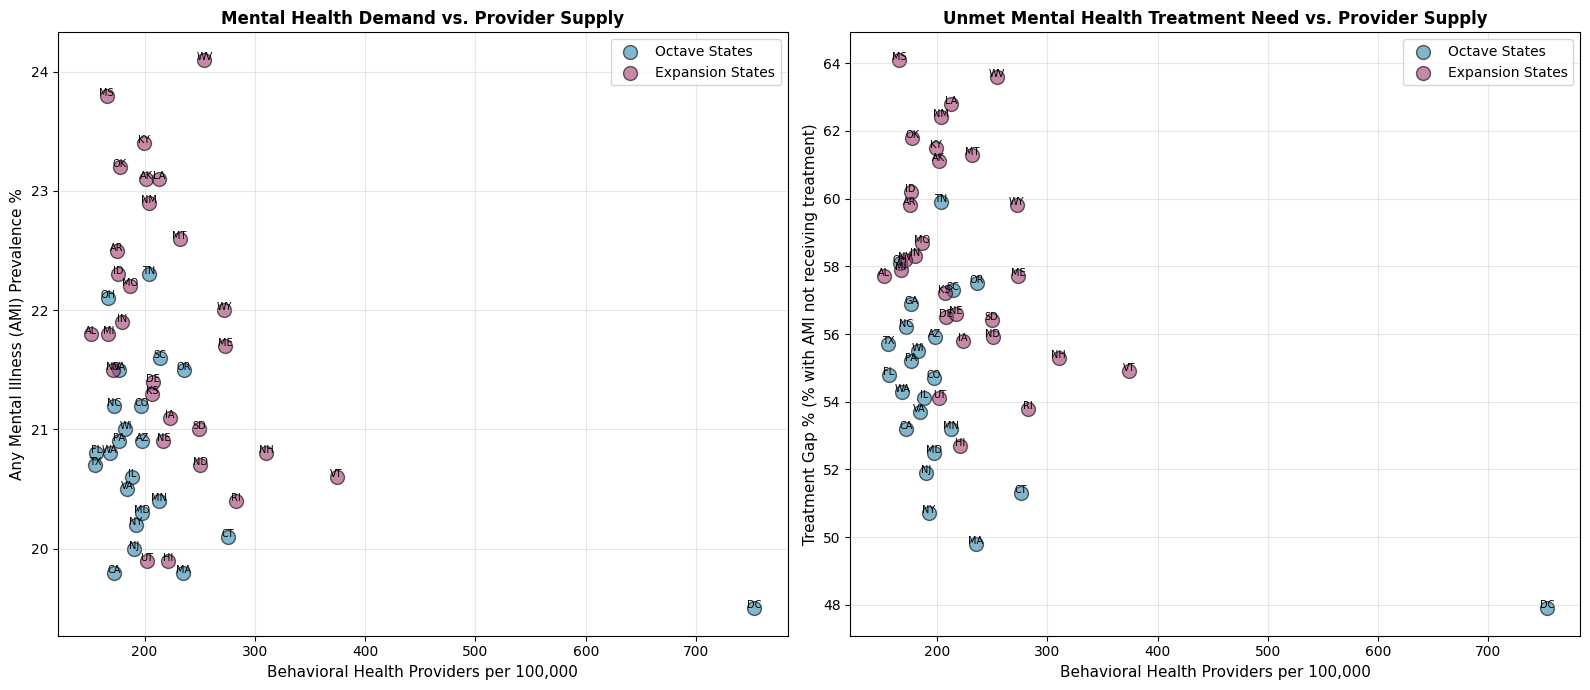

Saved: demand_supply_analysis.png


In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: Scatter - AMI Prevalence vs Providers per 100k
octave = df_demand[df_demand['is_octave_state'] == True]
expansion = df_demand[df_demand['is_octave_state'] == False]

ax1.scatter(octave['providers_per_100k'], octave['ami_prevalence_pct'], s=100, alpha=0.6, color='#2E86AB', label='Octave States', edgecolors='black')
ax1.scatter(expansion['providers_per_100k'], expansion['ami_prevalence_pct'], s=100, alpha=0.6, color='#A23B72', label='Expansion States', edgecolors='black')

for idx, row in df_demand.iterrows():
    ax1.annotate(row['state_abbrev'], (row['providers_per_100k'], row['ami_prevalence_pct']), fontsize=7, ha='center')

ax1.set_xlabel('Behavioral Health Providers per 100,000', fontsize=11)
ax1.set_ylabel('Any Mental Illness (AMI) Prevalence %', fontsize=11)
ax1.set_title('Mental Health Demand vs. Provider Supply', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: Scatter - Treatment Gap vs Providers per 100k
ax2.scatter(octave['providers_per_100k'], octave['treatment_gap_pct'], s=100, alpha=0.6, color='#2E86AB', label='Octave States', edgecolors='black')
ax2.scatter(expansion['providers_per_100k'], expansion['treatment_gap_pct'], s=100, alpha=0.6, color='#A23B72', label='Expansion States', edgecolors='black')

for idx, row in df_demand.iterrows():
    ax2.annotate(row['state_abbrev'], (row['providers_per_100k'], row['treatment_gap_pct']), fontsize=7, ha='center')

ax2.set_xlabel('Behavioral Health Providers per 100,000', fontsize=11)
ax2.set_ylabel('Treatment Gap % (% with AMI not receiving treatment)', fontsize=11)
ax2.set_title('Unmet Mental Health Treatment Need vs. Provider Supply', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'demand_supply_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: demand_supply_analysis.png")

## 8. Visualization: Treatment Gap by State

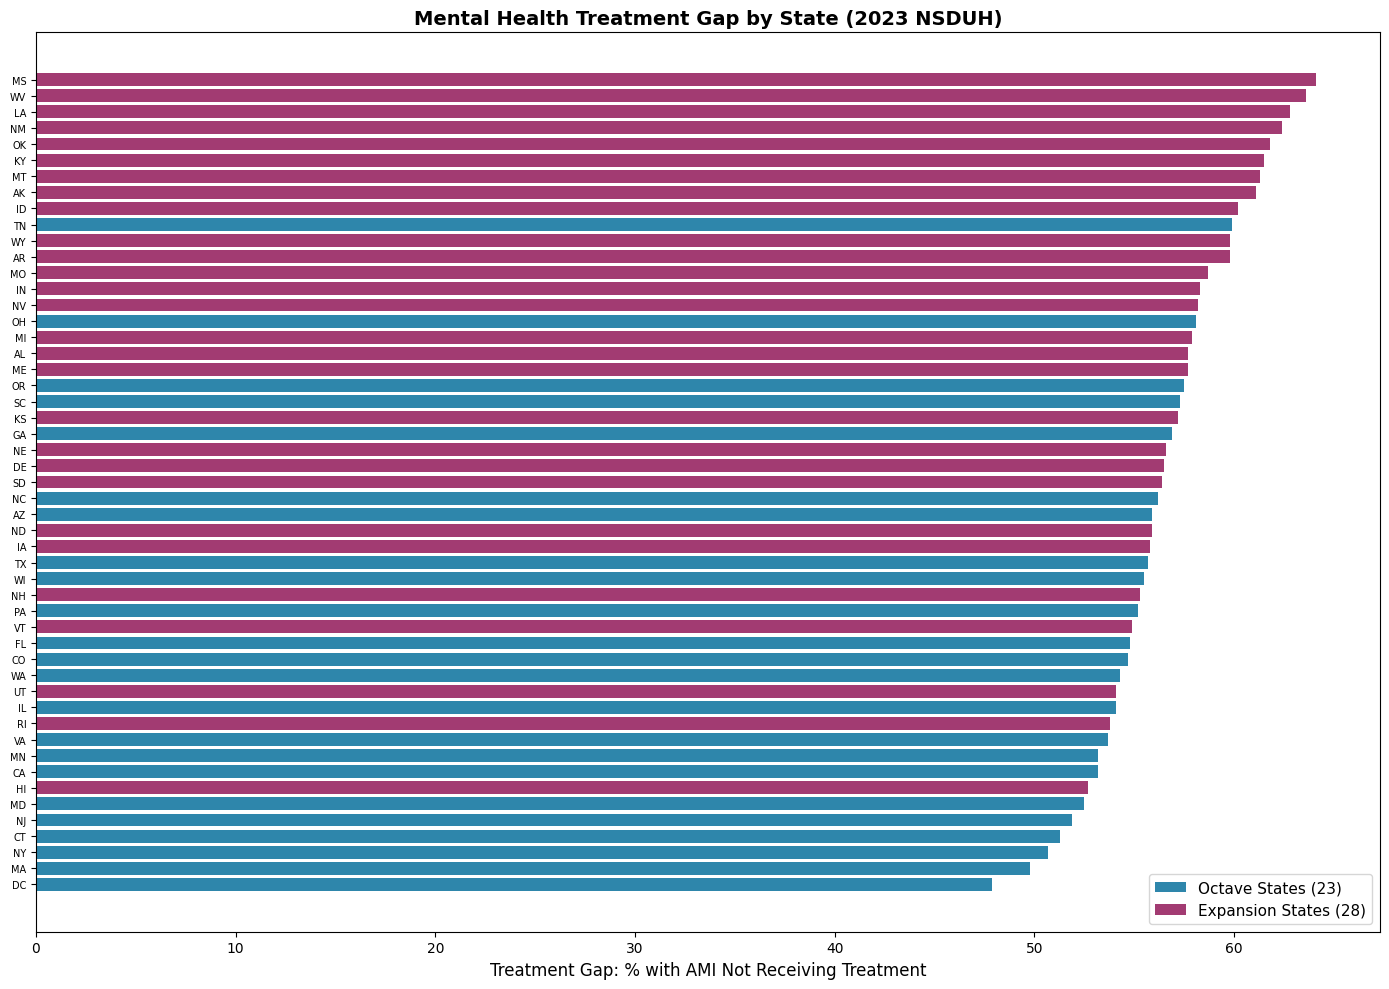

Saved: treatment_gap_by_state.png


In [9]:
fig, ax = plt.subplots(figsize=(14, 10))

df_plot = df_demand.sort_values('treatment_gap_pct', ascending=True)
colors = ['#2E86AB' if x else '#A23B72' for x in df_plot['is_octave_state']]

ax.barh(df_plot['state_abbrev'], df_plot['treatment_gap_pct'], color=colors)
ax.set_xlabel('Treatment Gap: % with AMI Not Receiving Treatment', fontsize=12)
ax.set_title('Mental Health Treatment Gap by State (2023 NSDUH)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=7)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', label=f'Octave States ({octave.shape[0]})'),
    Patch(facecolor='#A23B72', label=f'Expansion States ({expansion.shape[0]})')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'treatment_gap_by_state.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: treatment_gap_by_state.png")

## 9. Save Output

In [10]:
# --- Save the mental health demand table ---

output_path = os.path.join(OUTPUT_DIR, 'state_mental_health_demand.csv')
df_demand.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Shape: {df_demand.shape}")
print(f"\nColumns: {list(df_demand.columns)}")
print(f"\nThis output completes the data collection phase for the Octave Expansion Analysis.")
print(f"Outputs from NB01-NB04 provide the foundation for market sizing, expansion priority ranking, and opportunity assessment.")

Saved: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb04_mental_health_demand/state_mental_health_demand.csv
Shape: (51, 21)

Columns: ['state_name', 'state_abbrev', 'fips_code', 'is_octave_state', 'population_18_plus', 'ami_prevalence_pct', 'ami_population', 'smi_prevalence_pct', 'smi_population', 'mde_prevalence_pct', 'mde_population', 'sud_prevalence_pct', 'sud_population', 'received_treatment_coverage_pct', 'treatment_gap_pct', 'treatment_gap_population', 'mha_rank', 'mha_burden_percentile', 'providers_per_100k', 'ami_per_100k', 'demand_supply_ratio']

This output completes the data collection phase for the Octave Expansion Analysis.
Outputs from NB01-NB04 provide the foundation for market sizing, expansion priority ranking, and opportunity assessment.


---

## Summary: Data Collection Phase Complete

The following data products have been created for the Octave Behavioral Health Expansion Analysis:

### NB01: State Population & Demographics
- **Output:** `state_population_base.csv`
- **Content:** Population counts and demographics for all 51 states/jurisdictions, including Octave status flag

### NB02: Behavioral Health Provider Landscape
- **Output:** `state_provider_counts.csv`
- **Content:** BLS OES provider counts by specialty, state, and per-capita ratios

### NB03: Payer Mix & Insurance Coverage
- **Outputs:** `state_payer_mix.csv` and `state_octave_covered_lives.csv`
- **Content:** State insurance coverage breakdown and estimated covered lives under Octave payer partners

### NB04: Mental Health Demand Indicators
- **Output:** `state_mental_health_demand.csv`
- **Content:** SAMHSA NSDUH prevalence data, treatment gaps, MHA rankings, and demand-supply analysis

---

**Next Phase:** Analysis notebooks (NB05+) will synthesize these datasets to create expansion opportunity scoring, market sizing models, and strategic recommendations.